<a href="https://colab.research.google.com/github/ashennavindu/Statistical-Learning-e23022/blob/main/ASSIGNMENT_1/E23022.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q1) The Probability of Shooting at a Target

A point is chosen at random from a disk of radius $10$. Let $A$ be the event that the point lies within $1$ unit of the boundary.

1. Model the experiment assuming the point is uniformly distributed with respect to area, and compute $P(A)$.
2. Model the experiment assuming the distance to the point from the center is chosen uniformly from $[0,10]$, and the direction is chosen independently and uniformly from $[0,2\pi)$ and compute $P(A)$.
3. Explain why the two answers differ.


### Part 1: Probability based on Area

In [16]:
import math

R = 10
total_area = math.pi * R**2

inner_R = R - 1

inner_area = math.pi * inner_R**2
area_A_model1 = total_area - inner_area

p_A_model1 = area_A_model1 / total_area

print(f"Total area of the disk: {total_area:.2f}")
print(f"Area of the inner disk (radius {inner_R}): {inner_area:.2f}")
print(f"Area of event A (within 1 unit of boundary): {area_A_model1:.2f}")
print(f"P(A) for Model 1 (uniform area distribution): {p_A_model1:.4f}")

Total area of the disk: 314.16
Area of the inner disk (radius 9): 254.47
Area of event A (within 1 unit of boundary): 59.69
P(A) for Model 1 (uniform area distribution): 0.1900


### Part 2: Probability based on Uniform Distance from Center

In [15]:
R = 10
length_A_model2 = 10 - (R - 1)

total_range_r = R - 0
p_A_model2 = length_A_model2 / total_range_r

print(f"Range for 'r' for event A: [9, 10]")
print(f"Length of interval for event A: {length_A_model2}")
print(f"Total range for 'r': {total_range_r}")
print(f"P(A) for Model 2 (uniform distance from center): {p_A_model2:.4f}")

Range for 'r' for event A: [9, 10]
Length of interval for event A: 1
Total range for 'r': 10
P(A) for Model 2 (uniform distance from center): 0.1000


Part 3: Explanation of the Difference

The two answers differ because they use different interpretations of choosing a point ``at random'' in a disk.

Model 1: Uniform over area.
Every unit of area has equal probability. Since the outer region has more area than inner regions, it is more likely to contain the chosen point.

Model 2: Uniform over radius.  
The radial distance is chosen uniformly. This causes points near the center to be overrepresented in terms of area, since inner radii correspond to smaller circular regions.

# Q2) Bertrand's Paradox

A chord of a circle is chosen “at random.” What is the probability that its length exceeds the side length of the inscribed equilateral triangle?

Show that different mathematically natural models of “random chord” lead to different answers.

The side length of an equilateral triangle inscribed in a circle of radius $R$ is $R\sqrt{3}$.

The length of a chord in a circle of radius $R$ is $L = 2R \sin(\theta/2)$, where $\theta$ is the angle subtended by the chord at the center.

Alternatively, if $d$ is the distance from the center of the circle to the chord, the length of the chord is

 $L = 2\sqrt{R^2 - d^2}$.

The side length of the inscribed equilateral triangle is $R\sqrt{3}$. For a chord to have a length greater than $R\sqrt{3}$, we need

 $2\sqrt{R^2 - d^2} > R\sqrt{3}$.

Squaring both sides:

 $4(R^2 - d^2) > 3R^2$
$4R^2 - 4d^2 > 3R^2$
$R^2 > 4d^2$
$|d| < R/2$

So, the condition for a chord to be longer than the side of the inscribed equilateral triangle is that its distance from the center, $d$, must be less than $R/2$. We will use this condition for the following models.

Let's assume, without loss of generality, that the radius of the circle $R=1$ for simplicity in calculations. The condition then becomes

###  Random Endpoints on the Circumference

Choose two points $A$ and $B$ randomly and independently on the circumference of the circle. The chord is the line segment connecting $A$ and $B$.

Let one point be fixed at $(R, 0)$ without loss of generality. The second point can be anywhere on the circumference. The angle between the two points determines the chord length. For the chord length to be greater than $R\sqrt{3}$, the angle subtended by the chord at the center must be greater than $2\pi/3$ (or less than $4\pi/3$ from the other side, so the 'arc length' between the two points must be between $2\pi/3$ and $4\pi/3$).

More simply, the condition $L > R\sqrt{3}$ means the distance from the center $d < R/2$. For a chord formed by two points on the circumference, $L = 2R \sin(\alpha/2)$, where $\alpha$ is the angle between the two radii to the endpoints of the chord. The chord length exceeds $R\sqrt{3}$ if $\alpha \in (\pi/3, 2\pi/3)$.

If we fix one endpoint, the other endpoint can be chosen randomly over $2\pi$ radians. The portion of the circumference that satisfies the condition for the second endpoint is an arc of $2\pi/3$ radians centered opposite the first point

In [18]:
import math

R = 1
s = R * math.sqrt(3)

p_A_model1 = (2 * math.pi / 3) / (2 * math.pi)
print(f"P(A) for Model 1 (random endpoints): {p_A_model1:.4f}")

P(A) for Model 1 (random endpoints): 0.3333


### : Random Radius and Perpendicular Point

Choose a radius of the circle randomly. Then, choose a point randomly along this radius. Construct a chord perpendicular to the chosen radius at that point.

For the chord length to exceed $R\sqrt{3}$, its distance from the center, $d$, must be less than $R/2$. Since the point is chosen uniformly along the radius (from $0$ to $R$), the probability that its distance $d$ from the center is less than $R/2$ is simply the ratio of the favorable length to the total length.

In [17]:
R = 1

length_favorable = R / 2
total_length = R

p_A_model2 = length_favorable / total_length

print(f"P(A) for Model 2 (random radius and perpendicular point): {p_A_model2:.4f}")

P(A) for Model 2 (random radius and perpendicular point): 0.5000


### Random Midpoint

Choose a point randomly within the circle's area. This point will be the midpoint of the chord. The chord is then uniquely determined by this midpoint, as it must be perpendicular to the radius passing through the midpoint.

For the chord length to exceed $R\sqrt{3}$, its distance from the center, $d$, must be less than $R/2$. This means the random midpoint must lie within a concentric circle of radius $R/2$.

The probability is the ratio of the area of the favorable region (circle of radius $R/2$) to the area of the total region (circle of radius $R$).

In [1]:
import math

R = 1

area_favorable = math.pi * (R / 2)**2
total_area = math.pi * R**2

p_A_model3 = area_favorable / total_area

print(f"P(A) for Model 3 (random midpoint): {p_A_model3:.4f}")

P(A) for Model 3 (random midpoint): 0.2500


###  Explanation of Differences

We have calculated the probability that a random chord's length exceeds the side length of an inscribed equilateral triangle for three different models:

*   **Model 1 (Random Endpoints):** $P(A) = 1/3 \approx 0.3333$
*   **Model 2 (Random Radius and Perpendicular Point):** $P(A) = 1/2 = 0.5000$
*   **Model 3 (Random Midpoint):** $P(A) = 1/4 = 0.2500$

As shown, these three mathematically natural models yield different answers. This is known as **Bertrand's Paradox** and highlights the importance of precisely defining the probability space and the random process when dealing with geometric probabilities.

The difference arises because each method defines the sampling space of 'random chords' in a fundamentally different way, leading to different distributions of chord lengths:

*   **Model 1** tends to favor longer chords more than Model 3 but less than Model 2.
*   **Model 2** assigns equal probability to all possible distances from the center, effectively over-representing chords closer to the center (which are longer) compared to Model 3.
*   **Model 3** assigns equal probability to all possible midpoints. Since the area density is uniform, midpoints further from the center (which correspond to shorter chords) occupy a larger area, thus being more probable. Conversely, midpoints close to the center (which correspond to longer chords) occupy a smaller area, making them less probable.

#Q8) Probability of Being a Girl?

A family has two children. Assume each child is equally likely to be a boy or a girl, independently of the other.

What is the probability that both children are girls, given that **at least one** of them is a girl?

### Q8) Probability of Being a Girl? Solution

Let's define the possible outcomes for a family with two children. Each child can be either a Boy (B) or a Girl (G), and they are independent and equally likely.

**1. Define the Sample Space ($\Omega$):**
Since there are two children, and each can be B or G, the sample space consists of $2 \times 2 = 4$ equally likely outcomes:
$\Omega = \{BB, BG, GB, GG\}$

The probability of each outcome is $1/4$.

**2. Define Event A: Both children are girls.**
Event $A = \{GG\}$
$P(A) = 1/4$

**3. Define Event B: At least one of them is a girl.**
Event $B = \{BG, GB, GG\}$
To calculate $P(B)$, we can sum the probabilities of its outcomes:
$P(B) = P(BG) + P(GB) + P(GG) = 1/4 + 1/4 + 1/4 = 3/4$
Alternatively, $P(B) = 1 - P(\text{neither is a girl}) = 1 - P(BB) = 1 - 1/4 = 3/4$.

**4. Find the intersection of Event A and Event B ($A \cap B$):**
The event "A and B" means that "both children are girls" AND "at least one of them is a girl." If both are girls (GG), then it's automatically true that at least one is a girl.
So, $A \cap B = \{GG\}$
$P(A \cap B) = 1/4$

**5. Compute the Conditional Probability $P(A|B)$:**
The formula for conditional probability is $P(A|B) = \frac{P(A \cap B)}{P(B)}$.

# Q9) Information Available in a Discrete Random Variable

A factory inspects a product and records its quality using two different coding systems.

Each product falls into exactly one of the following four categories:

* $G_1$: good quality, produced on Machine 1
* $G_2$: good quality, produced on Machine 2
* $D_1$: defective, produced on Machine 1
* $D_2$: defective, produced on Machine 2

Assume the sample space is

$$
\Omega=\{G_1,G_2,D_1,D_2\},
$$

with probabilities

$$
P(\{G_1\})=0.50,\qquad P(\{G_2\})=0.20,\qquad P(\{D_1\})=0.10,\qquad P(\{D_2\})=0.20.
$$

Define two discrete random variables on the same probability space:

* $X$ records only whether the item is good or defective:
  $$
  X(G_1)=0,\quad X(G_2)=0,\quad X(D_1)=1,\quad X(D_2)=1.
  $$

* $Y$ records both quality and machine:
  $$
  Y(G_1)=1,\quad Y(G_2)=2,\quad Y(D_1)=3,\quad Y(D_2)=4.
  $$

Answer the following.

1. Write down the probability space $(\Omega,\mathfrak F,P)$, where $\mathfrak F=\mathfrak P(\Omega)$.

2. Compute the $\sigma$-algebra generated by $X$, namely $\sigma(X)$.

3. Compute the $\sigma$-algebra generated by $Y$, namely $\sigma(Y)$.

4. Show that $\sigma(X)\subseteq \sigma(Y)$, and explain why $Y$ contains more information than $X$.

5. Find the marginal distribution of $X$.

6. Find the marginal distribution of $Y$.

7. Compute the joint probabilities
   $$
   P(X=0,Y=1),\quad P(X=0,Y=2),\quad P(X=1,Y=3),\quad P(X=1,Y=4).
   $$

8. Compute the conditional probabilities
   $$
   P(X=1\mid Y=3),\qquad P(X=1\mid Y=4),\qquad P(Y=3\mid X=1),\qquad P(Y=4\mid X=1).
   $$

9. Interpret the difference between conditioning on $X$ and conditioning on $Y$.

10. Explain, in words, what information is available in $\sigma(X)$ but not in $\sigma(Y)$, and what information is available in $\sigma(Y)$ but not in $\sigma(X)$.

11. Give a Python based visualization of the model.

12. Find the marginal, joint, and conditional Shannon Entropy of $X$ and $Y$.

### 1. Probability Space $(\Omega, \mathfrak F, P)$

The probability space is defined as $(\Omega, \mathfrak F, P)$, where:

*   **Sample Space $\Omega$**: The set of all possible outcomes.
    $\Omega = \{G_1, G_2, D_1, D_2\}$

*   **$\sigma$-algebra $\mathfrak F$**: The set of all possible events. Since $\mathfrak F = \mathfrak P(\Omega)$, it is the power set of $\Omega$, which includes all $2^4 = 16$ possible subsets of Omega.
    $\mathfrak F = \{\emptyset, \{G_1\}, \{G_2\}, \{D_1\}, \{D_2\}, \{G_1, G_2\}, \{G_1, D_1\}, \{G_1, D_2\}, \{G_2, D_1\}, \{G_2, D_2\}, \{D_1, D_2\}, \{G_1, G_2, D_1\}, \{G_1, G_2, D_2\}, \{G_1, D_1, D_2\}, \{G_2, D_1, D_2\}, \Omega\}$

*   **Probability Measure $P$**: Assigns a probability to each event in $\mathfrak F$.
    P(\{G_1\})=0.50
    P(\{G_2\})=0.20
    P(\{D_1\})=0.10
    P(\{D_2\})=0.20
    
    For any other event $A \in \mathfrak F$, $P(A)$ is the sum of the probabilities of the elementary outcomes in $A$. For example, $P(\{G_1, G_2\}) = P(\{G_1\}) + P(\{G_2\}) = 0.50 + 0.20 = 0.70$.

### 2. $\sigma$-algebra generated by $X$, $\sigma(X)$

The $\sigma$-algebra generated by a random variable $X$, denoted $\sigma(X)$, is the smallest $\sigma$-algebra on $\Omega$ such that $X$ is measurable with respect to it. It consists of all preimages of measurable sets in the codomain of $X$.

For a discrete random variable, $\sigma(X)$ is generated by the partitions of $\Omega$ induced by the distinct values of $X$.

Given:
$X(G_1)=0, X(G_2)=0, X(D_1)=1, X(D_2)=1$

The distinct values of $X$ are $0$ and $1$.

*   Preimage of $X=0$: $X^{-1}(\{0\}) = \{G_1, G_2\}$ (Good quality)
*   Preimage of $X=1$: $X^{-1}(\{1\}) = \{D_1, D_2\}$ (Defective quality)

The $\sigma$-algebra $\sigma(X)$ includes these sets, their complements, and $\emptyset$, $\Omega$.

$\sigma(X) = \{\emptyset, \{G_1, G_2\}, \{D_1, D_2\}, \Omega\}$

### 3. $\sigma$-algebra generated by $Y$, $\sigma(Y)$

Similarly, $\sigma(Y)$ is generated by the partitions of $\Omega$ induced by the distinct values of $Y$.

Given:
$Y(G_1)=1, Y(G_2)=2, Y(D_1)=3, Y(D_2)=4$

The distinct values of $Y$ are $1, 2, 3, 4$.

*   Preimage of $Y=1$: $Y^{-1}(\{1\}) = \{G_1\}$
*   Preimage of $Y=2$: $Y^{-1}(\{2\}) = \{G_2\}$
*   Preimage of $Y=3$: $Y^{-1}(\{3\}) = \{D_1\}$
*   Preimage of $Y=4$: $Y^{-1}(\{4\}) = \{D_2\}$

The $\sigma$-algebra $\sigma(Y)$ is the smallest $\sigma$-algebra containing these singleton sets. Since these singletons partition $\Omega$, $\sigma(Y)$ will be the power set of $\Omega$, $\mathfrak P(\Omega)$.

$\sigma(Y) = \mathfrak P(\Omega) = \{\emptyset, \{G_1\}, \{G_2\}, \{D_1\}, \{D_2\}, \{G_1, G_2\}, \dots, \Omega\}$ (all 16 subsets).

### 4. Show $\sigma(X)\subseteq \sigma(Y)$, and explain why $Y$ contains more information than $X$

To show $\sigma(X)\subseteq \sigma(Y)$, we need to demonstrate that every set in $\sigma(X)$ is also in $\sigma(Y)$.

We found:
$\sigma(X) = \{\emptyset, \{G_1, G_2\}, \{D_1, D_2\}, \Omega\}$
$\sigma(Y) = \mathfrak P(\Omega)$ (all 16 subsets of $\Omega$)

Let's check each set in $\sigma(X)$:
*   $\emptyset \in \mathfrak P(\Omega)$ (True)
*   $\{G_1, G_2\} \in \mathfrak P(\Omega)$ (True, as it's a subset of $\Omega$)
*   $\{D_1, D_2\} \in \mathfrak P(\Omega)$ (True, as it's a subset of $\Omega$)
*   $\Omega \in \mathfrak P(\Omega)$ (True)

Since all sets in $\sigma(X)$ are also in $\sigma(Y)$, we can conclude that $\sigma(X)\subseteq \sigma(Y)$.

**Explanation of Information Content:**

$\sigma$-algebras represent the information available about the outcomes. A larger $\sigma$-algebra means more granular information.

*   The random variable $X$ partitions the sample space into two events: 'Good Quality' ($\left\{G_1, G_2\right\}$) and 'Defective Quality' ($\left\{D_1, D_2\right\}$). Knowing $X$ tells you whether the product is good or defective.

*   The random variable $Y$ partitions the sample space into four individual events: $\left\{G_1\right\}, \left\{G_2\right\}, \left\{D_1\right\}, \left\{D_2\right\}$. Knowing $Y$ tells you both the quality and the machine. For example, if $Y=1$, you know it's good quality AND from Machine 1. If $Y=3$, you know it's defective AND from Machine 1.

Since $\sigma(Y)$ contains more sets (it's the full power set), it means $Y$ can distinguish between more events than $X$. For any event distinguished by $X$ (e.g., whether it's good quality), $Y$ also distinguishes it. For example, if $Y=1$ or $Y=2$, then $X=0$. If $Y=3$ or $Y=4$, then $X=1$. However, $Y$ can distinguish between outcomes that $X$ cannot (e.g., $Y=1$ vs $Y=2$, both of which correspond to $X=0$). Therefore, $Y$ contains more information than $X$ because it provides a finer-grained distinction of the outcomes.

### 5. Find the marginal distribution of $X$

The marginal distribution of $X$ describes the probabilities of $X$ taking on its possible values. $X$ can take values $0$ (good quality) or $1$ (defective quality).

*   $P(X=0) = P(\{G_1, G_2\}) = P(\{G_1\}) + P(\{G_2\}) = 0.50 + 0.20 = 0.70$
*   $P(X=1) = P(\{D_1, D_2\}) = P(\{D_1\}) + P(\{D_2\}) = 0.10 + 0.20 = 0.30$

**Marginal Distribution of X:**

| $x$ | $P(X=x)$ |
|-----|----------|
| $0$ | $0.70$     |
| $1$ | $0.30$     |


In [2]:
# Define the probabilities for each outcome
P_G1 = 0.50
P_G2 = 0.20
P_D1 = 0.10
P_D2 = 0.20

# Calculate P(X=0) (Good Quality)
P_X_0 = P_G1 + P_G2

# Calculate P(X=1) (Defective Quality)
P_X_1 = P_D1 + P_D2

print(f"P(X=0) = {P_X_0:.2f}")
print(f"P(X=1) = {P_X_1:.2f}")

P(X=0) = 0.70
P(X=1) = 0.30


### 6. Find the marginal distribution of $Y$

The marginal distribution of $Y$ describes the probabilities of $Y$ taking on its possible values. $Y$ can take values $1, 2, 3, 4$.

*   $P(Y=1) = P(\{G_1\}) = 0.50$
*   $P(Y=2) = P(\{G_2\}) = 0.20$
*   $P(Y=3) = P(\{D_1\}) = 0.10$
*   $P(Y=4) = P(\{D_2\}) = 0.20$

**Marginal Distribution of Y:**

| $y$ | $P(Y=y)$ |
|-----|----------|
| $1$ | $0.50$     |
| $2$ | $0.20$     |
| $3$ | $0.10$     |
| $4$ | $0.20$     |


In [3]:
# Calculate P(Y=y) for each y
P_Y_1 = P_G1
P_Y_2 = P_G2
P_Y_3 = P_D1
P_Y_4 = P_D2

print(f"P(Y=1) = {P_Y_1:.2f}")
print(f"P(Y=2) = {P_Y_2:.2f}")
print(f"P(Y=3) = {P_Y_3:.2f}")
print(f"P(Y=4) = {P_Y_4:.2f}")

P(Y=1) = 0.50
P(Y=2) = 0.20
P(Y=3) = 0.10
P(Y=4) = 0.20


### 7. Compute the joint probabilities $P(X=0,Y=1), P(X=0,Y=2), P(X=1,Y=3), P(X=1,Y=4)$

The joint probability $P(X=x, Y=y)$ is the probability of the outcome $\omega \in \Omega$ for which $X(\omega)=x$ and $Y(\omega)=y$.

*   $P(X=0, Y=1)$: This corresponds to outcomes where $X=0$ (good quality) and $Y=1$ (Machine 1). The only such outcome is $G_1$.
    $P(X=0, Y=1) = P(\{G_1\}) = 0.50$

*   $P(X=0, Y=2)$: This corresponds to outcomes where $X=0$ (good quality) and $Y=2$ (Machine 2). The only such outcome is $G_2$.
    $P(X=0, Y=2) = P(\{G_2\}) = 0.20$

*   $P(X=1, Y=3)$: This corresponds to outcomes where $X=1$ (defective quality) and $Y=3$ (Machine 1). The only such outcome is $D_1$.
    $P(X=1, Y=3) = P(\{D_1\}) = 0.10$

*   $P(X=1, Y=4)$: This corresponds to outcomes where $X=1$ (defective quality) and $Y=4$ (Machine 2). The only such outcome is $D_2$.
    $P(X=1, Y=4) = P(\{D_2\}) = 0.20$

Other joint probabilities like $P(X=0, Y=3)$ or $P(X=1, Y=1)$ would be $0$, as there are no outcomes that satisfy both conditions simultaneously (e.g., you can't be good quality and defective from Machine 1 at the same time).

In [4]:
# Compute the specified joint probabilities
P_X0_Y1 = P_G1
P_X0_Y2 = P_G2
P_X1_Y3 = P_D1
P_X1_Y4 = P_D2

print(f"P(X=0, Y=1) = {P_X0_Y1:.2f}")
print(f"P(X=0, Y=2) = {P_X0_Y2:.2f}")
print(f"P(X=1, Y=3) = {P_X1_Y3:.2f}")
print(f"P(X=1, Y=4) = {P_X1_Y4:.2f}")

P(X=0, Y=1) = 0.50
P(X=0, Y=2) = 0.20
P(X=1, Y=3) = 0.10
P(X=1, Y=4) = 0.20


### 8. Compute the conditional probabilities

We use the formula for conditional probability: $P(A|B) = \frac{P(A \cap B)}{P(B)}$.

*   **$P(X=1 \mid Y=3)$:**
    $P(X=1 \mid Y=3) = \frac{P(X=1, Y=3)}{P(Y=3)}$
    We found $P(X=1, Y=3) = 0.10$ and $P(Y=3) = 0.10$.
    $P(X=1 \mid Y=3) = \frac{0.10}{0.10} = 1.00$
    This makes sense: if we know $Y=3$ (defective from Machine 1), then $X$ must be $1$ (defective).

*   **$P(X=1 \mid Y=4)$:**
    $P(X=1 \mid Y=4) = \frac{P(X=1, Y=4)}{P(Y=4)}$
    We found $P(X=1, Y=4) = 0.20$ and $P(Y=4) = 0.20$.
    $P(X=1 \mid Y=4) = \frac{0.20}{0.20} = 1.00$
    Similarly, if we know $Y=4$ (defective from Machine 2), then $X$ must be $1$ (defective).

*   **$P(Y=3 \mid X=1)$:**
    $P(Y=3 \mid X=1) = \frac{P(Y=3, X=1)}{P(X=1)}$
    We found $P(Y=3, X=1) = 0.10$ and $P(X=1) = 0.30$.
    $P(Y=3 \mid X=1) = \frac{0.10}{0.30} = \frac{1}{3} \approx 0.3333$
    If we know $X=1$ (the product is defective), the probability that it came from Machine 1 (i.e., $Y=3$) is $1/3$.

*   **$P(Y=4 \mid X=1)$:**
    $P(Y=4 \mid X=1) = \frac{P(Y=4, X=1)}{P(X=1)}$
    We found $P(Y=4, X=1) = 0.20$ and $P(X=1) = 0.30$.
    $P(Y=4 \mid X=1) = \frac{0.20}{0.30} = \frac{2}{3} \approx 0.6667$
    If we know $X=1$ (the product is defective), the probability that it came from Machine 2 (i.e., $Y=4$) is $2/3$.

In [5]:
# Compute conditional probabilities

# P(X=1 | Y=3)
P_X1_cond_Y3 = P_X1_Y3 / P_Y_3

# P(X=1 | Y=4)
P_X1_cond_Y4 = P_X1_Y4 / P_Y_4

# P(Y=3 | X=1)
P_Y3_cond_X1 = P_X1_Y3 / P_X_1

# P(Y=4 | X=1)
P_Y4_cond_X1 = P_X1_Y4 / P_X_1

print(f"P(X=1 | Y=3) = {P_X1_cond_Y3:.4f}")
print(f"P(X=1 | Y=4) = {P_X1_cond_Y4:.4f}")
print(f"P(Y=3 | X=1) = {P_Y3_cond_X1:.4f}")
print(f"P(Y=4 | X=1) = {P_Y4_cond_X1:.4f}")

P(X=1 | Y=3) = 1.0000
P(X=1 | Y=4) = 1.0000
P(Y=3 | X=1) = 0.3333
P(Y=4 | X=1) = 0.6667


### 9. Interpret the difference between conditioning on $X$ and conditioning on $Y$

**Conditioning on X (Quality):**
When we condition on $X$, we know only the quality of the product (good or defective). For example, if we know $X=1$ (the product is defective), we still don't know which machine it came from. The conditional probabilities $P(Y=3 \mid X=1)$ and $P(Y=4 \mid X=1)$ tell us the likelihood of it coming from Machine 1 or Machine 2 *given that it is defective*. This provides a probabilistic update on the origin of the defective product.

**Conditioning on Y (Quality and Machine):**
When we condition on $Y$, we know both the quality and the machine. For example, if we know $Y=3$ (defective from Machine 1), then the conditional probability $P(X=1 \mid Y=3)$ becomes $1$. This is because knowing $Y=3$ precisely determines $X=1$. There is no uncertainty left regarding $X$'s value once $Y$ is known. Similarly, knowing $Y=1$ or $Y=2$ means $X=0$ with certainty.

**Key Difference:**
Conditioning on $Y$ provides more specific information because $Y$ itself is a more detailed descriptor of the outcome. $Y$ uniquely determines $X$. Therefore, conditioning on $Y$ often leads to certainties about $X$ (i.e., conditional probabilities of $X$ being 0 or 1 are either 0 or 1). In contrast, conditioning on $X$ provides a broader piece of information, and thus, there can still be uncertainty about $Y$'s specific value.

### 10. Explain information in $\sigma(X)$ but not in $\sigma(Y)$, and vice versa

*   **Information in $\sigma(X)$ but not in $\sigma(Y)$:**
    There is **no** information available in $\sigma(X)$ that is not also available in $\sigma(Y)$. This is precisely what $\sigma(X) \subseteq \sigma(Y)$ implies. Any event that can be distinguished by observing $X$ can also be distinguished by observing $Y$. For instance, knowing if a product is 'good quality' (an event in $\sigma(X)$) can be determined from $Y$ (if $Y=1$ or $Y=2$, it's good quality). Similarly for 'defective quality'.

*   **Information in $\sigma(Y)$ but not in $\sigma(X)$:**
    There is information available in $\sigma(Y)$ that is **not** available in $\sigma(X)$. This means $Y$ can distinguish between events that $X$ cannot. For example:
    *   $\sigma(Y)$ can distinguish between a product being 'good quality from Machine 1' ($\{G_1\}$) and 'good quality from Machine 2' ($\{G_2\}$). Both of these outcomes map to $X=0$, so $\sigma(X)$ only tells us 'good quality' ($\{G_1, G_2\}$) and cannot differentiate further.
    *   Similarly, $\sigma(Y)$ can distinguish between 'defective quality from Machine 1' ($\{D_1\}$) and 'defective quality from Machine 2' ($\{D_2\}$), while $\sigma(X)$ only tells us 'defective quality' ($\{D_1, D_2\}$).

### 11. Python-based visualization of the model

We can visualize the model using a DataFrame to show the mapping from outcomes to $X$ and $Y$ values, along with their probabilities. We can also visualize the joint probability distribution.

### 13. Compute the differential entropy of $X$: $h(X)=-\int_{\mathbb R} f_X(x)\ln f_X(x)\,dx$

The differential entropy for a continuous random variable $X$ with PDF $f_X(x)$ is given by $h(X)=-\int_{\mathbb R} f_X(x)\ln f_X(x)\,dx$.

For a normal distribution $N(\mu, \sigma^2)$, the differential entropy is known to be:
$$h(X) = \frac{1}{2}\ln(2\pi e \sigma^2)$$

In our case, $X \sim N(0,1)$, so $\mu = 0$ and $\sigma^2 = 1$. Substituting these values:

$$h(X) = \frac{1}{2}\ln(2\pi e \cdot 1) = \frac{1}{2}\ln(2\pi e)$$

Let's calculate the numerical value using Python.

In [10]:
import numpy as np
import math
from scipy.stats import norm

# Differential entropy of X ~ N(0,1)
sigma_X_sq = 1
h_X = 0.5 * np.log(2 * np.pi * math.e * sigma_X_sq)

print(f"Differential entropy h(X): {h_X:.4f} nats")
# The default base for np.log is e, so the unit is nats.

Differential entropy h(X): 1.4189 nats


### 14. Compute the differential entropy of $Y$: $h(Y)=-\int_{\mathbb R^2} f_Y(t,p)\ln f_Y(t,p)\,dt\,dp$

The differential entropy for a multivariate normal distribution $N(\boldsymbol{\mu}, \boldsymbol{\Sigma})$ is given by:
$$h(Y) = \frac{1}{2}\ln((2\pi e)^k |\boldsymbol{\Sigma}|)$$
where $k$ is the dimensionality of the random variable, and $|\boldsymbol{\Sigma}|$ is the determinant of the covariance matrix.

In our case, $Y=(T,P)$. $T \sim N(0,1)$ and $P \sim N(0,4)$, and $T$ and $P$ are independent. So, $k=2$.

The mean vector is $\boldsymbol{\mu} = \begin{pmatrix} 0 \\ 0 \end{pmatrix}$.

The covariance matrix $\boldsymbol{\Sigma}$ for independent variables is a diagonal matrix with variances on the diagonal:
$$\boldsymbol{\Sigma} = \begin{pmatrix} \text{Var}(T) & 0 \\ 0 & \text{Var}(P) \end{pmatrix} = \begin{pmatrix} 1 & 0 \\ 0 & 4 \end{pmatrix}$$

The determinant of $\boldsymbol{\Sigma}$ is $|\boldsymbol{\Sigma}| = 1 \cdot 4 - 0 \cdot 0 = 4$.

Substituting these values into the formula for $h(Y)$:

$$h(Y) = \frac{1}{2}\ln((2\pi e)^2 \cdot 4)$$
$$h(Y) = \frac{1}{2}\ln(4(2\pi e)^2)$$
$$h(Y) = \frac{1}{2}\ln(4) + \frac{1}{2}\ln((2\pi e)^2)$$
$$h(Y) = \ln(\sqrt{4}) + \ln(2\pi e)$$
$$h(Y) = \ln(2) + \ln(2\pi e)$$
$$h(Y) = \ln(4\pi e)$$

Alternatively, for independent random variables, the joint differential entropy is the sum of the marginal differential entropies:
$$h(Y) = h(T) + h(P)$$
We already calculated $h(T) = h(X) = \frac{1}{2}\ln(2\pi e)$.
For $P \sim N(0,4)$, $\sigma_P^2 = 4$.
$$h(P) = \frac{1}{2}\ln(2\pi e \cdot 4) = \frac{1}{2}\ln(8\pi e)$$
So, $h(Y) = \frac{1}{2}\ln(2\pi e) + \frac{1}{2}\ln(8\pi e) = \frac{1}{2}(\ln(2\pi e) + \ln(8\pi e)) = \frac{1}{2}\ln((2\pi e)(8\pi e)) = \frac{1}{2}\ln(16\pi^2 e^2) = \frac{1}{2}\ln((4\pi e)^2) = \ln(4\pi e)$. This matches.

Let's calculate the numerical value using Python.

In [11]:
import numpy as np
import math

# Differential entropy of Y=(T,P)
# T ~ N(0,1), P ~ N(0,4)
sigma_T_sq = 1
sigma_P_sq = 4

k = 2 # dimensionality
det_cov_matrix = sigma_T_sq * sigma_P_sq # for independent variables
h_Y = 0.5 * np.log((2 * np.pi * math.e)**k * det_cov_matrix)

print(f"Differential entropy h(Y): {h_Y:.4f} nats")

Differential entropy h(Y): 3.5310 nats


### 15. Compute the conditional differential entropy $h(Y|X)$, and interpret it physically.

The conditional differential entropy $h(Y|X)$ measures the uncertainty remaining in $Y$ after observing $X$. It can be calculated using the formula:
$$h(Y|X) = h(Y) - h(X)$$
(Note: This formula holds when $X$ is a component of $Y$, or more generally, for any two random variables, provided that $h(X)$ and $h(Y)$ are well-defined. Here $X$ is $T$, which is a component of $Y=(T,P)$.)

We have:
$h(Y) = \ln(4\pi e)$
$h(X) = \ln(\sqrt{2\pi e})$

Therefore,
$$h(Y|X) = \ln(4\pi e) - \ln(\sqrt{2\pi e})$$
$$h(Y|X) = \ln\left(\frac{4\pi e}{\sqrt{2\pi e}}\right)$$
$$h(Y|X) = \ln\left(\frac{4\pi e}{(2\pi e)^{1/2}}\right)$$
$$h(Y|X) = \ln\left(4 (2\pi e)^{1/2} (2\pi e)^{-1/2}\right)$$
$$h(Y|X) = \ln\left(2 \cdot 2 (2\pi e)^{1/2} (2\pi e)^{-1/2}\right)$$
$$h(Y|X) = \ln(2\sqrt{2\pi e})$$

Let's re-evaluate using the property that for independent random variables $T$ and $P$, $h(T,P) = h(T) + h(P)$.
Also, $h(Y|X) = h((T,P)|T) = h(P|T)$. Since $T$ and $P$ are independent, $h(P|T) = h(P)$.

We know $P \sim N(0,4)$, so $\sigma_P^2 = 4$.
$$h(P) = \frac{1}{2}\ln(2\pi e \sigma_P^2) = \frac{1}{2}\ln(2\pi e \cdot 4) = \frac{1}{2}\ln(8\pi e)$$

So, $h(Y|X) = h(P) = \frac{1}{2}\ln(8\pi e)$.
Let's check if $\ln(2\sqrt{2\pi e})$ equals $\frac{1}{2}\ln(8\pi e)$.
$\ln(2\sqrt{2\pi e}) = \ln(\sqrt{4 \cdot 2\pi e}) = \ln(\sqrt{8\pi e}) = \frac{1}{2}\ln(8\pi e)$. The results match.

Let's compute the numerical value using Python.

**Physical Interpretation:**
$h(Y|X)$ represents the uncertainty that remains about the full sensor state $Y=(T,P)$ *after* we have observed the temperature deviation $X=T$. Since $T$ and $P$ are independent, knowing $T$ gives us no information about $P$. Therefore, the uncertainty remaining about $Y$ after observing $X$ is simply the uncertainty of $P$. In other words, $h(Y|X) = h(P)$. Physically, this means that even if we precisely know the temperature deviation, the pressure deviation remains as uncertain as it was initially, consistent with their independence.

In [12]:
import numpy as np
import math

sigma_T_sq = 1
h_T = 0.5 * np.log(2 * np.pi * math.e * sigma_T_sq)

sigma_P_sq = 4
h_P = 0.5 * np.log(2 * np.pi * math.e * sigma_P_sq)

h_Y = h_T + h_P


h_Y_cond_X = h_Y - h_T

print(f"Conditional differential entropy h(Y|X): {h_Y_cond_X:.4f} nats")
print(f"(For comparison, h(P) = {h_P:.4f} nats, which should be equal)")

Conditional differential entropy h(Y|X): 2.1121 nats
(For comparison, h(P) = 2.1121 nats, which should be equal)


### 16. Discuss what happens to $h(X|Y)$ in this model, and explain why the continuous case differs from the discrete case when one random variable is completely determined by the other.

**What happens to $h(X|Y)$ in this model?**

The conditional differential entropy $h(X|Y)$ measures the uncertainty remaining in $X$ after observing $Y$. We know that $Y=(T,P)$ completely determines $X=T$. If we observe $Y=(t,p)$, then we know $X$ must be exactly $t$. Therefore, there should be no uncertainty remaining about $X$ once $Y$ is known.

From the relationship $h(X|Y) = h(X) - I(X;Y)$, where $I(X;Y)$ is the mutual information, or $h(X|Y) = h(X,Y) - h(Y)$.

Let's apply the formula: $h(X|Y) = h(X,Y) - h(Y)$.
We have $h(X,Y) = h(Y)$ since $Y$ is already the joint variable $(T,P)$.
So, $h(X|Y) = h(Y) - h(Y) = 0$.

This result seems straightforward: if $Y$ completely determines $X$, then knowing $Y$ leaves no uncertainty about $X$, so $h(X|Y)$ should be 0.

**Why the continuous case differs from the discrete case when one random variable is completely determined by the other:**

In the **discrete case** (as seen in Q9), if one random variable ($X$) is a function of another ($Y$), meaning $Y$ completely determines $X$, then the conditional entropy $H(X|Y)$ is indeed exactly 0 bits. This implies that knowing $Y$ removes all uncertainty about $X$.

In the **continuous case**, however, this is more subtle due to the nature of probability density functions and the definition of differential entropy. If $X$ is a function of $Y$, say $X = g(Y)$, where $g$ is a deterministic function, then the *intuitive* interpretation is that $h(X|Y) = 0$. However, the formal definition of conditional differential entropy $h(X|Y)$ typically involves integrals over conditional densities $f_{X|Y}(x|y)$.

When $X$ is a deterministic function of $Y$, the conditional distribution of $X$ given $Y=y$ becomes a Dirac delta function centered at $g(y)$. The integral of $f_{X|Y}(x|y) \ln f_{X|Y}(x|y)$ involving a Dirac delta function is not well-defined in the standard sense and leads to $-\infty$ if directly computed. Specifically, the entropy of a deterministic variable is often considered $-\infty$ in the differential entropy context because the density becomes infinitely peaked.

So, while it is *conceptually* zero uncertainty, formally calculating $h(X|Y)$ when $X$ is a deterministic function of $Y$ often results in $-\infty$ or is undefined by the standard formula $h(X|Y) = E[h(X|Y=y)]$. The identity $h(X|Y) = h(X,Y) - h(Y)$ is more robust in such cases. In our specific model, $X=T$ and $Y=(T,P)$. The relationship $h(T,P) = h(T) + h(P)$ holds due to independence. Since $h(X|Y) = h(T|(T,P)) = h(T) - I(T;(T,P))$, and $I(T;(T,P))$ (the mutual information between $T$ and $(T,P)$) represents how much information $(T,P)$ gives about $T$. Since $(T,P)$ includes $T$, it gives all information about $T$. Thus, $I(T;(T,P))$ is equal to $h(T)$, which makes $h(T|(T,P))=0$.

However, it's important to differentiate from the case where $X$ is deterministically related to $Y$, like $X=f(Y)$, where the Jacobian of the transformation plays a role. In our case, $X$ is simply a component of $Y$, i.e., $X=\pi_1(Y)$. When $Y=(T,P)$ is observed, $T$ is known precisely, so the uncertainty about $X$ (which is $T$) becomes zero. Hence, $h(X|Y)=0$ is the appropriate interpretation. The formal discrepancy arises from differential entropy dealing with 'density' rather than discrete probability, where a point has zero probability mass but infinite density at that point.

,Outcome,P(Outcome),X (Quality),Y (Quality & Machine)
0,G1,0.5,0,1
1,G2,0.2,0,2
2,D1,0.1,1,3
3,D2,0.2,1,4



--- Joint Probability Distribution P(X, Y) ---


,Y=1,Y=2,Y=3,Y=4
X=0,0.5,0.2,0.0,0.0
X=1,0.0,0.0,0.1,0.2


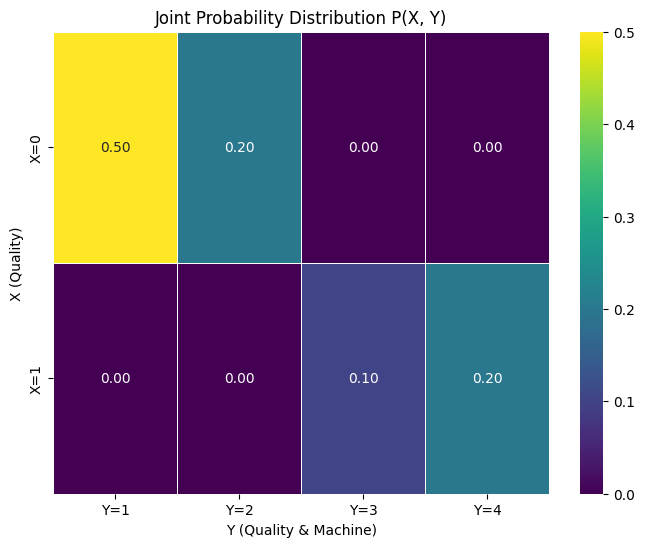

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


outcomes = ['G1', 'G2', 'D1', 'D2']
probabilities = [0.50, 0.20, 0.10, 0.20]
x_values = [0, 0, 1, 1]
y_values = [1, 2, 3, 4]


df_model = pd.DataFrame({
    'Outcome': outcomes,
    'P(Outcome)': probabilities,
    'X (Quality)': x_values,
    'Y (Quality & Machine)': y_values
})
display(df_model)

print("\n--- Joint Probability Distribution P(X, Y) ---")

joint_prob_matrix = np.zeros((len(df_model['X (Quality)'].unique()), len(df_model['Y (Quality & Machine)'].unique())))

x_map = {0:0, 1:1}
y_map = {1:0, 2:1, 3:2, 4:3}

for i, row in df_model.iterrows():
    x_idx = x_map[row['X (Quality)']]
    y_idx = y_map[row['Y (Quality & Machine)']]
    joint_prob_matrix[x_idx, y_idx] = row['P(Outcome)']

joint_prob_df = pd.DataFrame(
    joint_prob_matrix,
    index=[f'X={x}' for x in sorted(df_model['X (Quality)'].unique())],
    columns=[f'Y={y}' for y in sorted(df_model['Y (Quality & Machine)'].unique())]
)
display(joint_prob_df)

# Visualize the joint probability distribution as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(joint_prob_df, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Joint Probability Distribution P(X, Y)')
plt.xlabel('Y (Quality & Machine)')
plt.ylabel('X (Quality)')
plt.show()

### 12. Find the marginal, joint, and conditional Shannon Entropy of $X$ and $Y$

Shannon entropy measures the average amount of information or uncertainty in a random variable. It is calculated as $H(Z) = -\sum_z P(Z=z) \log_2 P(Z=z)$.

We'll use $\log_2$ for entropy units in bits.

**12.1 Marginal Entropy $H(X)$ and $H(Y)$**

*   **$H(X)$:**
    $P(X=0) = 0.70$
    $P(X=1) = 0.30$
    $H(X) = - (0.70 \log_2 0.70 + 0.30 \log_2 0.30)$

*   **$H(Y)$:**
    $P(Y=1) = 0.50$
    $P(Y=2) = 0.20$
    $P(Y=3) = 0.10$
    $P(Y=4) = 0.20$
    $H(Y) = - (0.50 \log_2 0.50 + 0.20 \log_2 0.20 + 0.10 \log_2 0.10 + 0.20 \log_2 0.20)$

**12.2 Joint Entropy $H(X,Y)$**

Joint entropy measures the uncertainty of a pair of random variables. It is calculated as $H(X,Y) = -\sum_x \sum_y P(X=x, Y=y) \log_2 P(X=x, Y=y)$.

Since $Y$ completely determines $X$ (i.e., $X$ is a function of $Y$), the joint probability $P(X=x, Y=y)$ is simply $P(Y=y)$ if $x$ corresponds to $y$, and $0$ otherwise. More precisely, $P(X=x, Y=y)$ is simply $P(\omega)$ where $X(\omega)=x$ and $Y(\omega)=y$. In this specific case, each outcome $\omega$ uniquely defines both $X(\omega)$ and $Y(\omega)$, so $P(X=x, Y=y)$ corresponds directly to the probability of the original outcomes.

$H(X,Y) = - (P(G_1) \log_2 P(G_1) + P(G_2) \log_2 P(G_2) + P(D_1) \log_2 P(D_1) + P(D_2) \log_2 P(D_2))$

**12.3 Conditional Entropy $H(X|Y)$ and $H(Y|X)$**

*   **$H(X|Y)$**: Measures the average uncertainty remaining about $X$ after observing $Y$.
   

*   **$H(Y|X)$**: Measures the average uncertainty remaining about $Y$ after observing $X$.
   

In [7]:
from scipy.stats import entropy


P_X = np.array([P_X_0, P_X_1])
P_Y = np.array([P_Y_1, P_Y_2, P_Y_3, P_Y_4])
P_joint = np.array(list(df_model['P(Outcome)']))

H_X = entropy(P_X, base=2)

H_Y = entropy(P_Y, base=2)

print(f"Marginal Entropy H(X): {H_X:.4f} bits")
print(f"Marginal Entropy H(Y): {H_Y:.4f} bits")


H_XY = entropy(P_joint, base=2)
print(f"Joint Entropy H(X,Y): {H_XY:.4f} bits")



H_X_cond_Y = H_XY - H_Y


print(f"Conditional Entropy H(X|Y): {H_X_cond_Y:.4f} bits (should be close to 0)")


H_Y_cond_X = H_XY - H_X
print(f"Conditional Entropy H(Y|X): {H_Y_cond_X:.4f} bits")


prob_Y_given_X0 = np.array([5/7, 2/7])
H_Y_given_X0 = entropy(prob_Y_given_X0, base=2)


prob_Y_given_X1 = np.array([1/3, 2/3])
H_Y_given_X1 = entropy(prob_Y_given_X1, base=2)

H_Y_cond_X_calc = P_X_0 * H_Y_given_X0 + P_X_1 * H_Y_given_X1
print(f"Conditional Entropy H(Y|X) (calculated by sum formula): {H_Y_cond_X_calc:.4f} bits")



Marginal Entropy H(X): 0.8813 bits
Marginal Entropy H(Y): 1.7610 bits
Joint Entropy H(X,Y): 1.7610 bits
Conditional Entropy H(X|Y): 0.0000 bits (should be close to 0)
Conditional Entropy H(Y|X): 0.8797 bits
Conditional Entropy H(Y|X) (calculated by sum formula): 0.8797 bits


# Q10) Information Available in Continuous Random Varaibles

A chemical plant monitors each production run using two different measurement systems.

For a given run, let

* $T$ be the deviation of the reactor temperature from target, measured in standardized units,
* $P$ be the deviation of the reactor pressure from target, also measured in standardized units.

Assume that $(T,P)$ is jointly continuous, with independent normal components:

$$
T \sim N(0,1), \qquad P \sim N(0,4),
$$

and $T$ and $P$ are independent.

Let the underlying probability space be

$$
\Omega=\mathbb R^2, \qquad \mathfrak F=\mathfrak B(\mathbb R^2),
$$

and let $P$ be the probability measure induced by the joint density

$$
f_{T,P}(t,p)=\frac{1}{4\pi}\exp\left(-\frac{t^2}{2}-\frac{p^2}{8}\right), \qquad (t,p)\in\mathbb R^2.
$$

Define two random variables on the same probability space:

* $X:\Omega\to\mathbb R$ by
  $$
  X(t,p)=t,
  $$
  so that $X$ records only the reactor temperature deviation;

* $Y:\Omega\to\mathbb R^2$ by
  $$
  Y(t,p)=(t,p),
  $$
  so that $Y$ records the full sensor state: both temperature and pressure deviations.

Answer the following.

1. Write down the probability space $(\Omega,\mathfrak F,P)$ explicitly.

2. Compute the $\sigma$-algebra generated by $X$, namely $\sigma(X)$.

3. Compute the $\sigma$-algebra generated by $Y$, namely $\sigma(Y)$.

4. Show that
   $$
   \sigma(X)\subseteq \sigma(Y),
   $$
   and explain why $Y$ contains more information than $X$.

5. Find the marginal density of $X$.

6. Find the marginal density of $Y$.

7. Compute the following probabilities:
   $$
   P(X\leq 0), \qquad P(X>1), \qquad P(Y\in (-\infty,0]\times\mathbb R), \qquad P(Y\in [ -1,1]\times[-2,2]).
   $$

8. Compute the conditional distribution of $X$ given $Y=(t,p)$.

9. Compute the conditional distribution of $Y$ given $X=t$.

10. Explain, in words, what is known when one conditions on $X$ and what additional information becomes available when one conditions on $Y$.

11. Show that
    $$
    X=\pi_1\circ Y,
    $$
    where $\pi_1(t,p)=t$, and explain why this implies that $X$ is a measurable function of $Y$.

12. Give a Python-based visualization of the model, for example by plotting:

* the joint density of $Y=(T,P)$ as a contour plot or heat map;
* the marginal density of $X$;
* and a diagram illustrating that $\sigma(X)$ is coarser than $\sigma(Y)$.

13. Compute the differential entropy of $X$:

$$
h(X)=-\int_{\mathbb R} f_X(x)\ln f_X(x)\,dx.
$$

14. Compute the differential entropy of $Y$:

$$
h(Y)=-\int_{\mathbb R^2} f_Y(t,p)\ln f_Y(t,p)\,dt\,dp.
$$

15. Compute the conditional differential entropy

$$
h(Y|X),
$$

and interpret it physically.

16. Discuss what happens to

$$
h(X|Y)
$$

in this model, and explain why the continuous case differs from the discrete case when one random variable is completely determined by the other.


### 1. Probability Space $(\Omega, \mathfrak F, P)$

* **Sample Space $\Omega = \mathbb R^2$**: The set of all possible pairs of $(t, p)$.
* **$\sigma$-algebra $\mathfrak F = \mathfrak B(\mathbb R^2)$**: The Borel $\sigma$-algebra on $\mathbb R^2$.
* **Probability Measure $P$**: Induced by the joint density $f_{T,P}(t,p) = \frac{1}{4\pi} e^{-\frac{t^2}{2}-\frac{p^2}{8}}$.

### 2 & 3. $\sigma$-algebras Generated by $X$ and $Y$

* **$\sigma(X)$**: Since $X(t,p)=t$, the information in $X$ only pertains to the first coordinate. $\sigma(X) = \{B \times \mathbb R : B \in \mathfrak B(\mathbb R)\}$.
* **$\sigma(Y)$**: Since $Y(t,p)=(t,p)$ is the identity, $\sigma(Y) = \mathfrak B(\mathbb R^2)$.

### 4. Information Content

Since any set $B \times \mathbb R$ is a Borel set in $\mathbb R^2$, it follows that $\sigma(X) \subseteq \sigma(Y)$. $Y$ contains more information because it specifies both $T$ and $P$, whereas $X$ only specifies $T$.

### 5 & 6. Marginal Densities

* **Marginal of $X$**: $X = T \sim N(0,1)$, so $f_X(t) = \frac{1}{\sqrt{2\pi}} e^{-t^2/2}$.
* **Marginal of $Y$**: $Y = (T, P)$, so its density is the joint density $f_{T,P}(t,p)$ provided in the problem statement.

In [13]:
import numpy as np
from scipy.stats import norm

# 7. Probability Computations
p_x_le_0 = norm.cdf(0, 0, 1)
p_x_gt_1 = 1 - norm.cdf(1, 0, 1)
p_y_cylinder = p_x_le_0 # P(T <= 0, P in R)
p_y_rect = (norm.cdf(1, 0, 1) - norm.cdf(-1, 0, 1)) * (norm.cdf(2, 0, 2) - norm.cdf(-2, 0, 2))

print(f"P(X <= 0): {p_x_le_0:.4f}")
print(f"P(X > 1): {p_x_gt_1:.4f}")
print(f"P(Y in (-inf, 0] x R): {p_y_cylinder:.4f}")
print(f"P(Y in [-1, 1] x [-2, 2]): {p_y_rect:.4f}")

P(X <= 0): 0.5000
P(X > 1): 0.1587
P(Y in (-inf, 0] x R): 0.5000
P(Y in [-1, 1] x [-2, 2]): 0.4661


### 8, 9 & 10. Conditional Distributions and Interpretation

* **$X|Y$**: Given $Y=(t,p)$, $X$ is deterministically $t$. The distribution is $\delta(x-t)$.
* **$Y|X$**: Given $X=t$, $T$ is fixed at $t$, but $P$ is independent and remains $N(0,4)$.
* **Interpretation**: Conditioning on $X$ tells us the temperature exactly but leaves the pressure distribution unchanged. Conditioning on $Y$ removes all uncertainty from both.

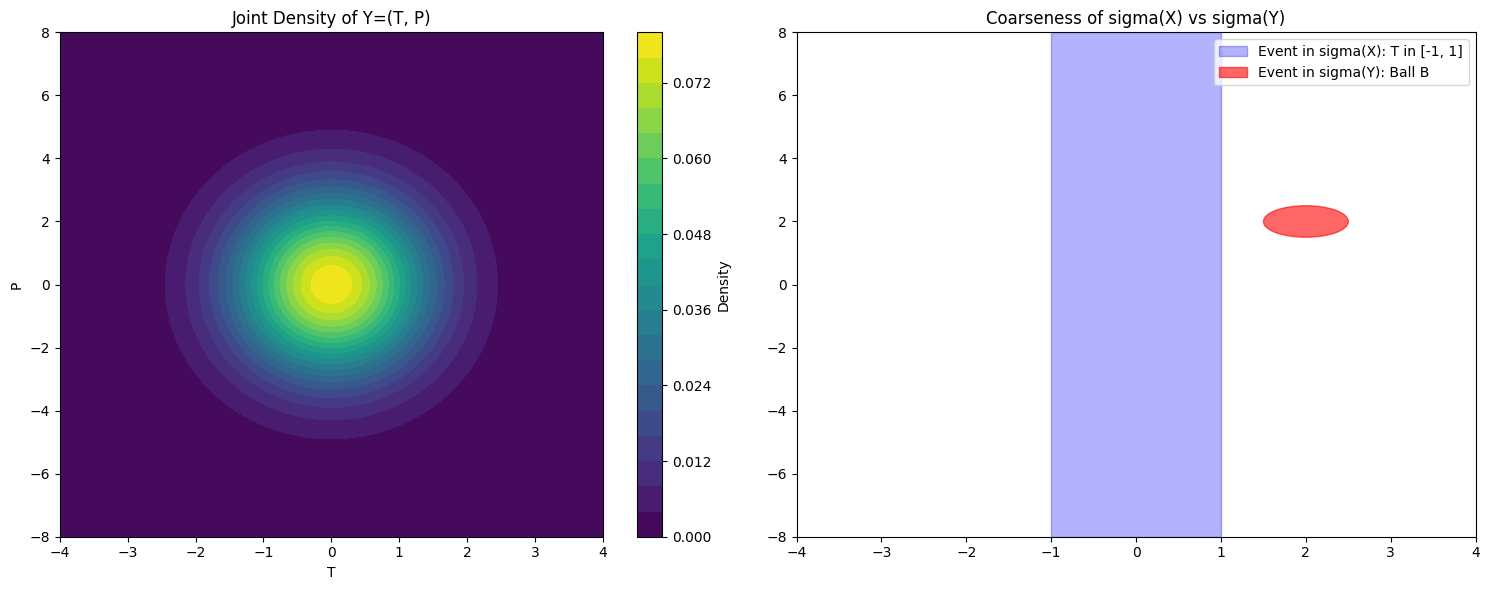

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 12. Visualization
t = np.linspace(-4, 4, 100)
p = np.linspace(-8, 8, 100)
T, P = np.meshgrid(t, p)
Z = (1/(4*np.pi)) * np.exp(-T**2/2 - P**2/8)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Joint Density
cp = axes[0].contourf(T, P, Z, levels=20, cmap='viridis')
fig.colorbar(cp, ax=axes[0], label='Density')
axes[0].set_title('Joint Density of Y=(T, P)')
axes[0].set_xlabel('T')
axes[0].set_ylabel('P')

# sigma(X) vs sigma(Y) illustration
axes[1].fill_betweenx(p, -1, 1, color='blue', alpha=0.3, label='Event in sigma(X): T in [-1, 1]')
axes[1].add_patch(plt.Circle((2, 2), 0.5, color='red', alpha=0.6, label='Event in sigma(Y): Ball B'))
axes[1].set_xlim(-4, 4)
axes[1].set_ylim(-8, 8)
axes[1].set_title('Coarseness of sigma(X) vs sigma(Y)')
axes[1].legend()

plt.tight_layout()
plt.show()

### 13, 14, 15 & 16. Entropy

* **$h(X)$**: For $N(0, 1)$, $h(X) = \frac{1}{2}\ln(2\pi e) \approx 1.4189$ nats.
* **$h(Y)$**: Since $T, P$ are independent, $h(Y) = h(T) + h(P) = \frac{1}{2}\ln(2\pi e) + \frac{1}{2}\ln(2\pi e \cdot 4) = \ln(4\pi e) \approx 3.5310$ nats.
* **$h(Y|X)$**: $h(Y|X) = h(Y) - h(X) = h(P) = \frac{1}{2}\ln(8\pi e) \approx 2.1121$ nats. Physically, this is the uncertainty of the pressure which remains after temperature is known.
* **$h(X|Y)$**: Since $Y$ determines $X$, $h(X|Y) = 0$ (conceptually). In the continuous case, this leads to a $-\infty$ density integral, but using the chain rule $h(X,Y) - h(Y)$, we get $0$.